In [1]:
print("Food Delivery Big Data Analytics Project")
print("PySpark setup is ready!")

Food Delivery Big Data Analytics Project
PySpark setup is ready!


In [2]:
from pyspark.sql import SparkSession

# Create Spark session
spark = SparkSession.builder \
    .appName("FoodDeliveryAnalytics") \
    .master("local[*]") \
    .getOrCreate()

print("Spark session created successfully!")

c:\Users\USHA SREE\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyspark\testing\utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Spark session created successfully!


In [4]:
# Load the food delivery dataset

file_path = "../data/food_delivery_dataset.csv"

df = spark.read.csv(
    file_path,
    header=True,
    inferSchema=True
)

print("Dataset loaded successfully!")
print("Number of rows:", df.count())
print("Number of columns:", len(df.columns))

df.printSchema()

Dataset loaded successfully!
Number of rows: 20000
Number of columns: 31
root
 |-- order_id: string (nullable = true)
 |-- restaurant_id: integer (nullable = true)
 |-- food_item: string (nullable = true)
 |-- order_time: date (nullable = true)
 |-- delivery_time: date (nullable = true)
 |-- delivery_distance: double (nullable = true)
 |-- order_value: double (nullable = true)
 |-- delivery_method: string (nullable = true)
 |-- traffic_condition: string (nullable = true)
 |-- weather_condition: string (nullable = true)
 |-- delivery_delay: double (nullable = true)
 |-- route_taken: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- location: string (nullable = true)
 |-- order_history: integer (nullable = true)
 |-- customer_rating: integer (nullable = true)
 |-- preferred_cuisine: string (nullable = true)
 |-- order_frequency: string (nullable = true)
 |-- loyalty_program: string (nullable 

In [5]:
# Display the first 5 rows of the dataset

df.show(5, truncate=False)

+---------+-------------+------------+----------+-------------+-----------------+-----------+---------------+-----------------+-----------------+--------------+-----------+-----------+---+------+---------+-------------+---------------+-----------------+---------------+---------------+----------------+--------------+-----------------+--------------+---------------------+-----------+-------------------+-------------+------------------+-----------------+
|order_id |restaurant_id|food_item   |order_time|delivery_time|delivery_distance|order_value|delivery_method|traffic_condition|weather_condition|delivery_delay|route_taken|customer_id|age|gender|location |order_history|customer_rating|preferred_cuisine|order_frequency|loyalty_program|food_temperature|food_freshness|packaging_quality|food_condition|customer_satisfaction|small_route|bike_friendly_route|route_type   |route_efficiency  |traffic_avoidance|
+---------+-------------+------------+----------+-------------+-----------------+-------

In [6]:
# Check for missing values in each column

from pyspark.sql.functions import col, sum

missing_values = df.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])

missing_values.show()

+--------+-------------+---------+----------+-------------+-----------------+-----------+---------------+-----------------+-----------------+--------------+-----------+-----------+---+------+--------+-------------+---------------+-----------------+---------------+---------------+----------------+--------------+-----------------+--------------+---------------------+-----------+-------------------+----------+----------------+-----------------+
|order_id|restaurant_id|food_item|order_time|delivery_time|delivery_distance|order_value|delivery_method|traffic_condition|weather_condition|delivery_delay|route_taken|customer_id|age|gender|location|order_history|customer_rating|preferred_cuisine|order_frequency|loyalty_program|food_temperature|food_freshness|packaging_quality|food_condition|customer_satisfaction|small_route|bike_friendly_route|route_type|route_efficiency|traffic_avoidance|
+--------+-------------+---------+----------+-------------+-----------------+-----------+---------------+---

In [7]:
# Dataset summary

print("Total rows:", df.count())
print("Total columns:", len(df.columns))

print("\nColumn names:")
print(df.columns)

print("\nStatistical summary:")
df.describe().show()

Total rows: 20000
Total columns: 31

Column names:
['order_id', 'restaurant_id', 'food_item', 'order_time', 'delivery_time', 'delivery_distance', 'order_value', 'delivery_method', 'traffic_condition', 'weather_condition', 'delivery_delay', 'route_taken', 'customer_id', 'age', 'gender', 'location', 'order_history', 'customer_rating', 'preferred_cuisine', 'order_frequency', 'loyalty_program', 'food_temperature', 'food_freshness', 'packaging_quality', 'food_condition', 'customer_satisfaction', 'small_route', 'bike_friendly_route', 'route_type', 'route_efficiency', 'traffic_avoidance']

Statistical summary:
+-------+---------+------------------+----------+------------------+------------------+---------------+-----------------+-----------------+-----------------+-----------+-----------+------------------+------+---------+------------------+------------------+-----------------+---------------+---------------+----------------+------------------+------------------+--------------+--------------

In [8]:
# Most popular food items

from pyspark.sql.functions import count, col

popular_foods = (
    df.groupBy("food_item")
      .agg(count("*").alias("total_orders"))
      .orderBy(col("total_orders").desc())
)

popular_foods.show(10, truncate=False)

+--------------+------------+
|food_item     |total_orders|
+--------------+------------+
|Pasta         |1884        |
|Whole cake    |958         |
|Soup          |948         |
|Cup cake      |944         |
|Beef pie      |934         |
|Chicken rice  |934         |
|Cookie        |930         |
|CoffeeBoba tea|922         |
|Chicken wings |918         |
|Pizza         |916         |
+--------------+------------+
only showing top 10 rows


In [9]:
# Delivery method analysis

delivery_methods = (
    df.groupBy("delivery_method")
      .agg(count("*").alias("total_orders"))
      .orderBy(col("total_orders").desc())
)

delivery_methods.show(truncate=False)


+---------------+------------+
|delivery_method|total_orders|
+---------------+------------+
|Walk           |6830        |
|Bike           |6598        |
|Car            |6572        |
+---------------+------------+



In [10]:
# Average delivery delay by delivery method

avg_delay = (
    df.groupBy("delivery_method")
      .agg(
          avg("delivery_delay").alias("average_delay")
      )
      .orderBy(col("average_delay").desc())
)

avg_delay.show(truncate=False)

NameError: name 'avg' is not defined

In [11]:
# Import the average function
from pyspark.sql.functions import avg

# Average delivery delay by delivery method
avg_delay = (
    df.groupBy("delivery_method")
      .agg(
          avg("delivery_delay").alias("average_delay")
      )
      .orderBy(col("average_delay").desc())
)

avg_delay.show(truncate=False)

+---------------+-----------------+
|delivery_method|average_delay    |
+---------------+-----------------+
|Car            |5.213557516737694|
|Bike           |4.951679296756598|
|Walk           |4.701865300146413|
+---------------+-----------------+



In [12]:
# Average delivery delay by traffic condition

traffic_delay = (
    df.groupBy("traffic_condition")
      .agg(
          avg("delivery_delay").alias("average_delay")
      )
      .orderBy(col("average_delay").desc())
)

traffic_delay.show(truncate=False)

+-----------------+-----------------+
|traffic_condition|average_delay    |
+-----------------+-----------------+
|Low              |5.051724748966353|
|High             |4.980851715686275|
|Medium           |4.82434925373134 |
+-----------------+-----------------+



In [13]:
# Average delivery delay by weather condition

weather_delay = (
    df.groupBy("weather_condition")
      .agg(
          avg("delivery_delay").alias("average_delay")
      )
      .orderBy(col("average_delay").desc())
)

weather_delay.show(truncate=False)

+-----------------+------------------+
|weather_condition|average_delay     |
+-----------------+------------------+
|Sunny            |5.0329256594724345|
|Snowy            |4.950746135552951 |
|Rainy            |4.872745454545433 |
+-----------------+------------------+



In [14]:
# Average order value by delivery method

avg_order_value = (
    df.groupBy("delivery_method")
      .agg(
          avg("order_value").alias("average_order_value")
      )
      .orderBy(col("average_order_value").desc())
)

avg_order_value.show(truncate=False)

+---------------+-------------------+
|delivery_method|average_order_value|
+---------------+-------------------+
|Car            |27.644695678636644 |
|Walk           |27.466131771595894 |
|Bike           |26.89105486511063  |
+---------------+-------------------+



In [15]:
# Average customer rating by delivery method

rating_analysis = (
    df.groupBy("delivery_method")
      .agg(
          avg("customer_rating").alias("average_rating")
      )
      .orderBy(col("average_rating").desc())
)

rating_analysis.show(truncate=False)

+---------------+------------------+
|delivery_method|average_rating    |
+---------------+------------------+
|Car            |3.039866098600122 |
|Walk           |3.0248901903367496|
|Bike           |3.0157623522279478|
+---------------+------------------+



In [16]:
# Most popular locations by number of orders

location_analysis = (
    df.groupBy("location")
      .agg(
          count("*").alias("total_orders")
      )
      .orderBy(col("total_orders").desc())
)

location_analysis.show(10, truncate=False)

+---------+------------+
|location |total_orders|
+---------+------------+
|Ahmedabad|2051        |
|Kolkata  |2032        |
|Delhi    |2027        |
|Pune     |2026        |
|Jaipur   |2013        |
|Chennai  |1998        |
|Mumbai   |1980        |
|Hyderabad|1973        |
|Bangalore|1968        |
|Lucknow  |1932        |
+---------+------------+



In [17]:
# Average order value by food item

food_value_analysis = (
    df.groupBy("food_item")
      .agg(
          avg("order_value").alias("average_order_value"),
          count("*").alias("total_orders")
      )
      .orderBy(col("average_order_value").desc())
)

food_value_analysis.show(10, truncate=False)

+--------------+-------------------+------------+
|food_item     |average_order_value|total_orders|
+--------------+-------------------+------------+
|Fried chicken |28.343310961968687 |894         |
|Shawarma      |27.922883295194502 |874         |
|Cup cake      |27.92188559322035  |944         |
|Pizza         |27.899104803493454 |916         |
|Pasta         |27.71757961783442  |1884        |
|Chicken rice  |27.69000000000002  |934         |
|CoffeeBoba tea|27.648741865509756 |922         |
|Chicken pie   |27.42250549450548  |910         |
|Cookie        |27.347698924731173 |930         |
|Beef pie      |27.25663811563168  |934         |
+--------------+-------------------+------------+
only showing top 10 rows


c:\Users\USHA SREE\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\USHA SREE\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyspark\sql\pandas\conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


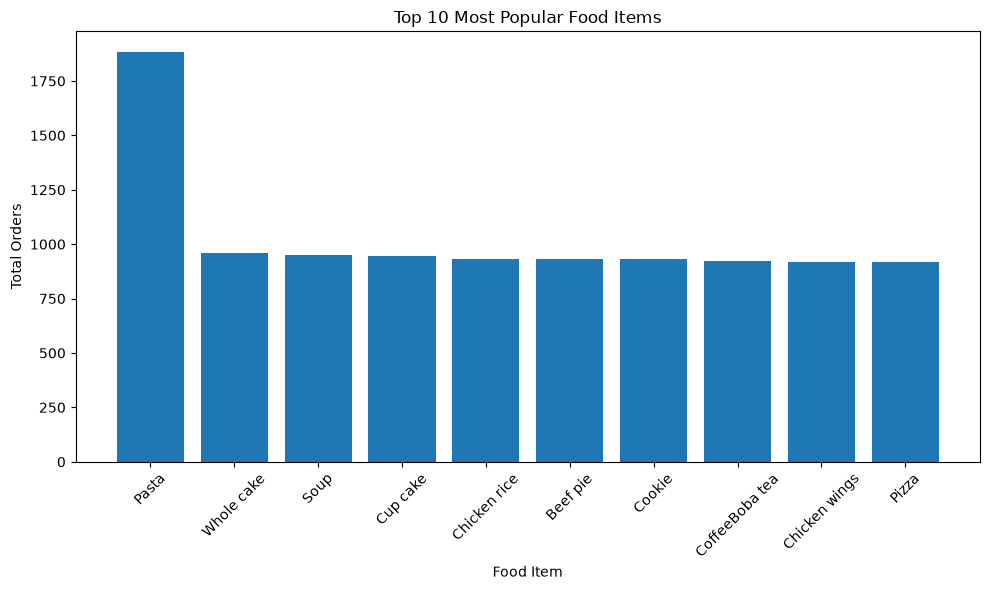

In [18]:
# Most popular food items - Bar chart

import matplotlib.pyplot as plt

popular_foods_pd = popular_foods.limit(10).toPandas()

plt.figure(figsize=(10, 6))
plt.bar(popular_foods_pd["food_item"], popular_foods_pd["total_orders"])

plt.title("Top 10 Most Popular Food Items")
plt.xlabel("Food Item")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

c:\Users\USHA SREE\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\USHA SREE\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyspark\sql\pandas\conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


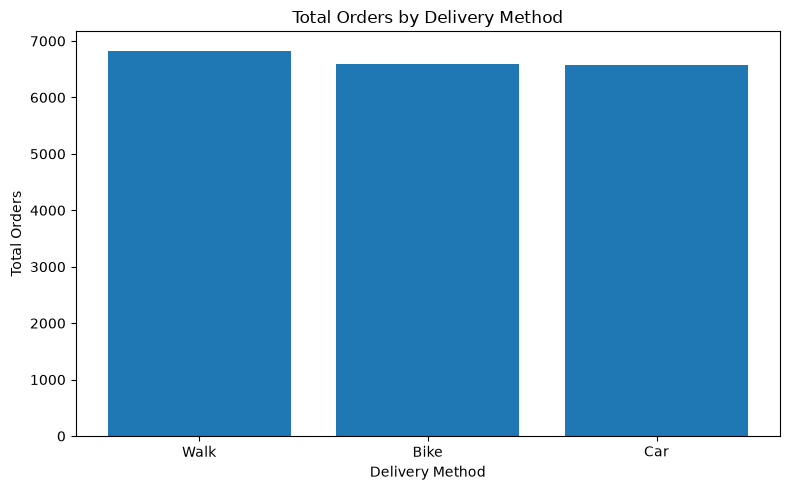

In [19]:
# Delivery method analysis - Bar chart

delivery_methods_pd = delivery_methods.toPandas()

plt.figure(figsize=(8, 5))
plt.bar(
    delivery_methods_pd["delivery_method"],
    delivery_methods_pd["total_orders"]
)

plt.title("Total Orders by Delivery Method")
plt.xlabel("Delivery Method")
plt.ylabel("Total Orders")
plt.tight_layout()
plt.show()

c:\Users\USHA SREE\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\USHA SREE\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyspark\sql\pandas\conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


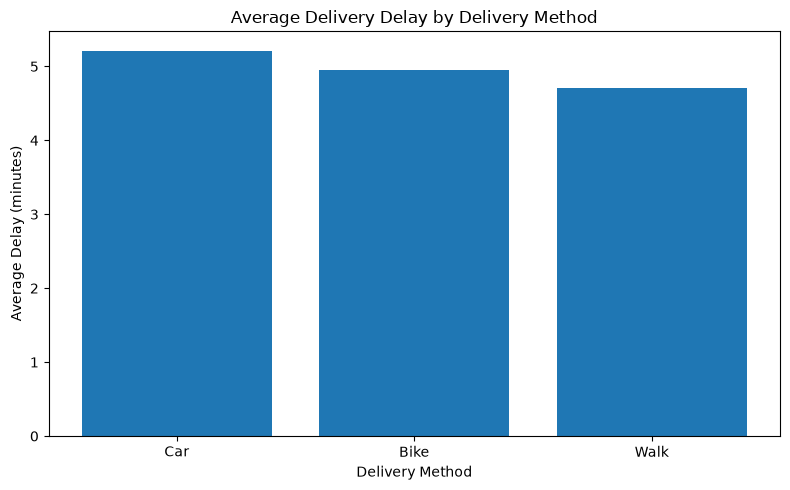

In [20]:
# Average delivery delay by delivery method - Bar chart

avg_delay_pd = avg_delay.toPandas()

plt.figure(figsize=(8, 5))
plt.bar(
    avg_delay_pd["delivery_method"],
    avg_delay_pd["average_delay"]
)

plt.title("Average Delivery Delay by Delivery Method")
plt.xlabel("Delivery Method")
plt.ylabel("Average Delay (minutes)")
plt.tight_layout()
plt.show()

c:\Users\USHA SREE\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\USHA SREE\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyspark\sql\pandas\conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


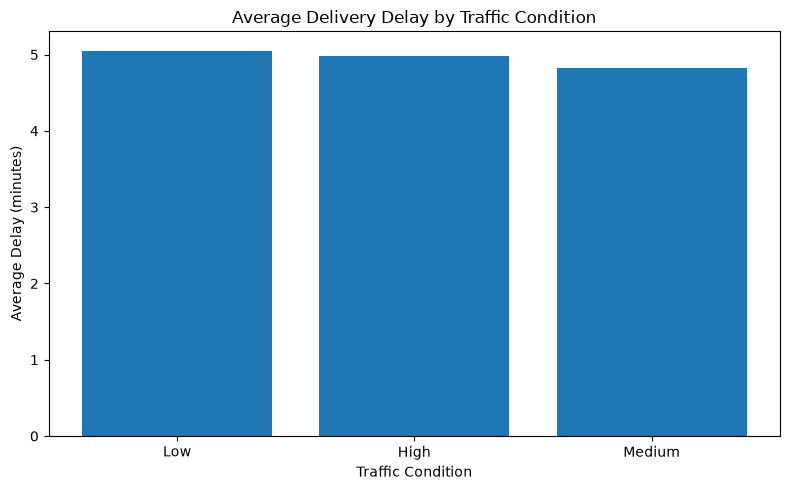

In [21]:
# Average delivery delay by traffic condition - Bar chart

traffic_delay_pd = traffic_delay.toPandas()

plt.figure(figsize=(8, 5))
plt.bar(
    traffic_delay_pd["traffic_condition"],
    traffic_delay_pd["average_delay"]
)

plt.title("Average Delivery Delay by Traffic Condition")
plt.xlabel("Traffic Condition")
plt.ylabel("Average Delay (minutes)")
plt.tight_layout()
plt.show()

c:\Users\USHA SREE\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\USHA SREE\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyspark\sql\pandas\conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


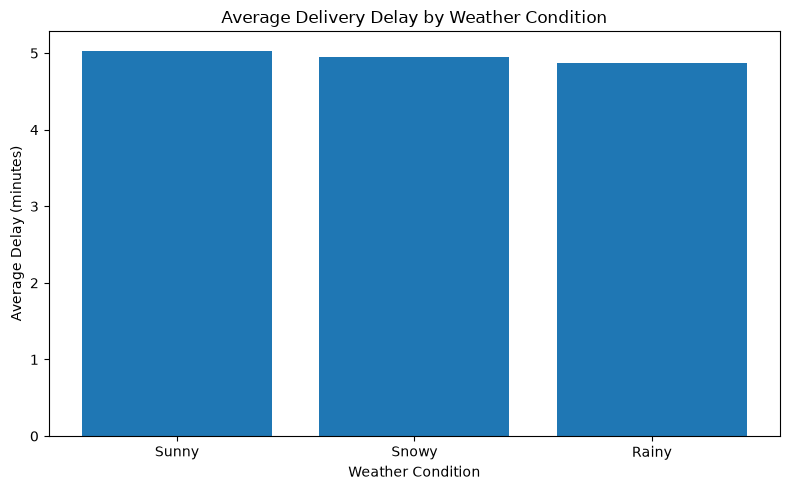

In [22]:
# Average delivery delay by weather condition - Bar chart

weather_delay_pd = weather_delay.toPandas()

plt.figure(figsize=(8, 5))
plt.bar(
    weather_delay_pd["weather_condition"],
    weather_delay_pd["average_delay"]
)

plt.title("Average Delivery Delay by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Delay (minutes)")
plt.tight_layout()
plt.show()